## How are in-demand skills trending for Data Analysts?
##### Methodology
1. Aggregate skill counts monthly
2. Re-analyze based on percentage of total jobs
3. Plot the monthly skill demand

### Import Libraries and Data

In [1]:
# Importing Libraries
import ast
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt  

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x: ast.literal_eval(x) if pd.notna(x) else x)

### Analyze Skill Trends Over Time

To understand how in-demand skills evolve, I focus on Data Analyst job postings in France and analyze how skill demand changes over time.  
By structuring the data at the skill level and aggregating it by month, I can track trends in skill popularity.

In [ ]:
# Filter Data Analyst roles in France and prepare data for time-based skill analysis
df_DA_FR = df[(df['job_title'] == 'Data Analyst') & (df['job_country'] == 'France')].copy()

# Extract month from posting date to analyze trends over time
df_DA_FR['job_posted_month_no'] = df_DA_FR['job_posted_date'].dt.month

# Split multiple skills into individual rows for accurate aggregation
df_DA_FR_explode = df_DA_FR.explode('job_skills')

### Prepare Data for Trend Analysis

To analyze how skill demand evolves over time in France, I restructure the data into a format suitable for time series analysis.  
This allows me to track the monthly frequency of each skill and identify trends in the French job market for Data Analysts.

In [3]:
df_DA_FR_pivot = df_DA_FR_explode.pivot_table(index='job_posted_month_no', columns='job_skills',  aggfunc='size', fill_value=0)

df_DA_FR_pivot

job_skills,airflow,alteryx,angular,ansible,asana,asp.net,assembly,atlassian,aws,azure,...,trello,typescript,unify,unix,vba,visio,vmware,vue,windows,word
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,6,3,1,0,1,0,0,0,2,8,...,1,0,0,0,7,2,0,8,1,4
2,10,5,1,0,2,0,0,0,11,11,...,0,0,0,0,11,2,0,9,0,3
3,11,4,2,1,0,0,0,0,7,10,...,0,0,0,1,6,1,0,7,1,1
4,5,2,0,1,0,0,0,0,12,15,...,0,0,1,0,9,3,0,2,1,0
5,13,1,0,0,0,0,0,0,12,9,...,0,0,1,0,11,6,0,4,2,0
6,9,1,0,0,0,0,2,0,4,8,...,0,0,0,0,6,1,0,1,0,0
7,1,0,0,0,0,0,0,0,6,8,...,0,0,0,1,3,1,0,1,0,0
8,2,2,0,0,0,0,0,0,7,17,...,5,0,0,1,5,0,1,2,2,1
9,2,1,0,1,0,1,0,0,3,2,...,0,1,0,0,6,1,0,2,0,0


### Prioritize the Most In-Demand Skills

To focus the analysis on the most relevant skills in France, I rank them based on their overall frequency across all months.  
This ensures that the analysis highlights the most important and consistently demanded skills in the French Data Analyst job market.

In [8]:
# Rank skills by total frequency to focus on the most in-demand ones in France
df_DA_FR_pivot.loc['Total'] = df_DA_FR_pivot.sum()
df_DA_FR_pivot = df_DA_FR_pivot[df_DA_FR_pivot.loc['Total'].sort_values(ascending=False).index]
df_DA_FR_pivot = df_DA_FR_pivot.drop('Total')

df_DA_FR_pivot

job_skills,sql,python,tableau,power bi,excel,sas,r,azure,gcp,vba,...,drupal,terminal,asp.net,symphony,typescript,atlassian,bitbucket,slack,symfony,ms access
job_posted_month_no,,,,,,,,,,,,,,,,,,,,,
1,88,57,44,33,30,50,17,8,9,7,...,0,1,0,0,0,0,0,1,0,0
2,85,55,46,44,32,36,19,11,8,11,...,0,0,0,0,0,0,0,0,0,0
3,86,59,48,41,25,18,26,10,6,6,...,1,0,0,1,0,0,1,0,1,0
4,67,47,30,38,26,24,19,15,10,9,...,0,0,0,0,0,0,0,0,0,0
5,73,61,44,30,22,20,22,9,15,11,...,0,0,0,0,0,0,0,0,0,1
6,55,42,25,27,16,12,16,8,8,6,...,0,0,0,0,0,0,0,0,0,0
7,48,28,24,22,12,4,13,8,7,3,...,0,0,0,0,0,0,0,0,0,0
8,60,49,28,33,18,18,11,17,4,5,...,0,0,0,0,0,0,0,0,0,0
9,21,19,13,17,14,6,5,2,3,6,...,0,0,1,0,1,0,0,0,0,0


### Visualize Skill Trends Over Time

I visualize the evolution of the most in-demand skills for Data Analysts in France on a monthly basis.  
This allows me to identify which skills are consistently demanded, as well as those gaining or losing popularity over time.

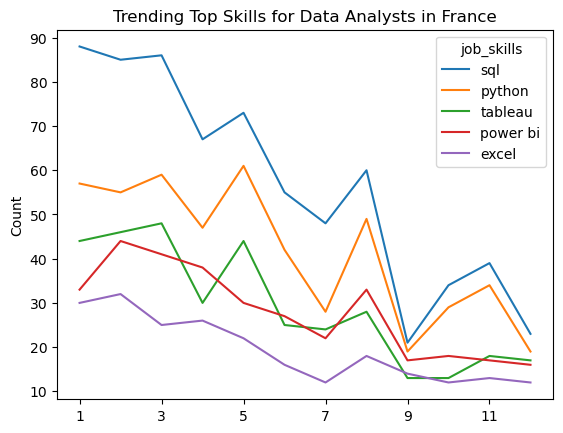

In [9]:
df_DA_FR_pivot.iloc[:, :5].plot(kind='line')

plt.title('Trending Top Skills for Data Analysts in France')
plt.ylabel('Count')
plt.xlabel('')
plt.show()

### Calculate Percentage of Total Jobs

To accurately interpret skill trends over time, I calculate the total number of Data Analyst job postings for each month.  
This provides a baseline to convert skill counts into percentages and ensure meaningful comparisons across time.

In [10]:
DA_totals = df_DA_FR.groupby('job_posted_month_no').size()

DA_totals

job_posted_month_no
1     141
2     149
3     153
4     130
5     135
6      93
7      60
8      95
9      59
10     59
11     68
12     63
dtype: int64

In [ ]:
# Convert monthly skill counts into percentages to normalize trends over time
df_DA_FR_percent = df_DA_FR_pivot.iloc[:12].div(DA_totals/100, axis=0)

# Format month labels for better readability
df_DA_FR_percent = df_DA_FR_percent.reset_index()
df_DA_FR_percent['job_posted_month'] = df_DA_FR_percent['job_posted_month_no'].apply(lambda x: pd.to_datetime(x, format='%m').strftime('%b'))
df_DA_FR_percent = df_DA_FR_percent.set_index('job_posted_month')
df_DA_FR_percent = df_DA_FR_percent.drop(columns='job_posted_month_no')

df_DA_FR_percent

job_skills,sql,python,tableau,power bi,excel,sas,r,azure,gcp,vba,...,drupal,terminal,asp.net,symphony,typescript,atlassian,bitbucket,slack,symfony,ms access
job_posted_month,,,,,,,,,,,,,,,,,,,,,
Jan,62.411348,40.425532,31.205674,23.404255,21.276596,35.460993,12.056738,5.673759,6.382979,4.964539,...,0.000000,0.70922,0.000000,0.000000,0.000000,0.000000,0.000000,0.70922,0.000000,0.000000
Feb,57.046980,36.912752,30.872483,29.530201,21.476510,24.161074,12.751678,7.382550,5.369128,7.382550,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Mar,56.209150,38.562092,31.372549,26.797386,16.339869,11.764706,16.993464,6.535948,3.921569,3.921569,...,0.653595,0.00000,0.000000,0.653595,0.000000,0.000000,0.653595,0.00000,0.653595,0.000000
Apr,51.538462,36.153846,23.076923,29.230769,20.000000,18.461538,14.615385,11.538462,7.692308,6.923077,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
May,54.074074,45.185185,32.592593,22.222222,16.296296,14.814815,16.296296,6.666667,11.111111,8.148148,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.740741
Jun,59.139785,45.161290,26.881720,29.032258,17.204301,12.903226,17.204301,8.602151,8.602151,6.451613,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Jul,80.000000,46.666667,40.000000,36.666667,20.000000,6.666667,21.666667,13.333333,11.666667,5.000000,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Aug,63.157895,51.578947,29.473684,34.736842,18.947368,18.947368,11.578947,17.894737,4.210526,5.263158,...,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000
Sep,35.593220,32.203390,22.033898,28.813559,23.728814,10.169492,8.474576,3.389831,5.084746,10.169492,...,0.000000,0.00000,1.694915,0.000000,1.694915,0.000000,0.000000,0.00000,0.000000,0.000000


### Visualize Monthly Skill Demand

I visualize the monthly evolution of the most in-demand skills for Data Analysts in France as a percentage of total job postings.  
This highlights which skills are consistently important, as well as those gaining or losing relevance over time.

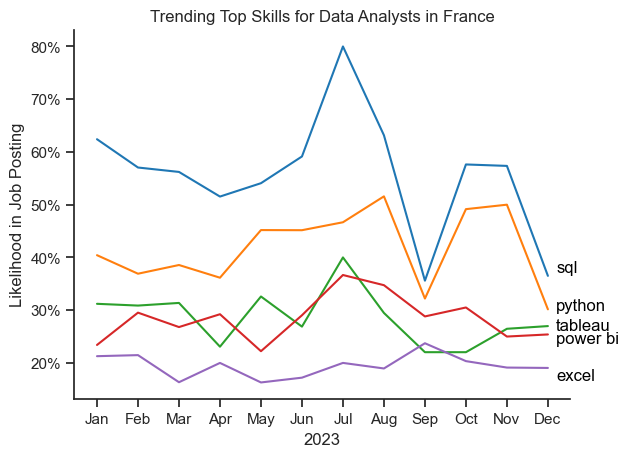

In [ ]:
import numpy as np

df_plot = df_DA_FR_percent.iloc[:, :5]

sns.lineplot(data=df_plot, dashes=False, legend=False, palette='tab10')
sns.set_theme(style='ticks')
sns.despine()


plt.title('Trending Top Skills for Data Analysts in France')
plt.ylabel('Likelihood in Job Posting')
plt.xlabel('2023')
plt.gca().yaxis.set_major_formatter(PercentFormatter(decimals=0))

# Get last values and sort to avoid overlap
last_values = df_plot.iloc[-1].sort_values()

# Add small vertical offsets
offsets = np.linspace(-1.5, 1.5, len(last_values))

for i, (skill, value) in enumerate(last_values.items()):
    plt.text(11.2, value + offsets[i], skill, color='black', va='center')

plt.show()